# 05 NLP Portuguese Review Analysis v2

Notebook ini menganalisis teks review Brazilian Portuguese untuk menjawab: apa yang dikeluhkan pelanggan dengan low rating, bagaimana low-rating berbeda dari high-rating, dan apakah BERTopic dapat membantu interpretasi dibanding TF-IDF/NMF/LDA.

Catatan leakage: review text tidak digunakan sebagai fitur prediksi ML low-rating karena teks muncul setelah review dikirim. NLP ini hanya untuk analisis deskriptif/root-cause.

## 1. Imports and Path Setup

In [1]:
from pathlib import Path
from collections import Counter
import json
import re
import unicodedata
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_PATH = ROOT / 'data' / 'raw' / 'order_reviews.csv'
OUT_DIR = ROOT / 'data' / 'processed'
ASSET_DIR = ROOT / 'docs' / 'assets' / 'nlp_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.max_rows', 100)

NORMALIZED_TOKEN_PATTERN = r'[a-z_]+'
RANDOM_STATE = 42

## 2. Load Dataset

In [2]:
reviews = pd.read_csv(RAW_PATH)
print('Dataset shape:', reviews.shape)
reviews.head()

Dataset shape: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01 00:00:00,2018-03-02 10:26:53


## 3. Initial Audit and EDA

In [3]:
title_has_text = reviews['review_comment_title'].fillna('').str.strip().ne('')
message_has_text = reviews['review_comment_message'].fillna('').str.strip().ne('')
any_text = title_has_text | message_has_text
audit_base = {
    'total_reviews': int(len(reviews)),
    'reviews_with_any_text': int(any_text.sum()),
    'low_rating_reviews': int(reviews['review_score'].le(2).sum()),
    'low_rating_reviews_with_text': int((reviews['review_score'].le(2) & any_text).sum()),
}
audit_base['percentage_reviews_with_text'] = round(audit_base['reviews_with_any_text'] * 100 / audit_base['total_reviews'], 2)
audit_base['percentage_low_rating_with_text'] = round(audit_base['low_rating_reviews_with_text'] * 100 / max(audit_base['low_rating_reviews'], 1), 2)
pd.Series(audit_base)

total_reviews                      99224.00
reviews_with_any_text              42687.00
low_rating_reviews                 14575.00
low_rating_reviews_with_text       10994.00
percentage_reviews_with_text          43.02
percentage_low_rating_with_text       75.43
dtype: float64

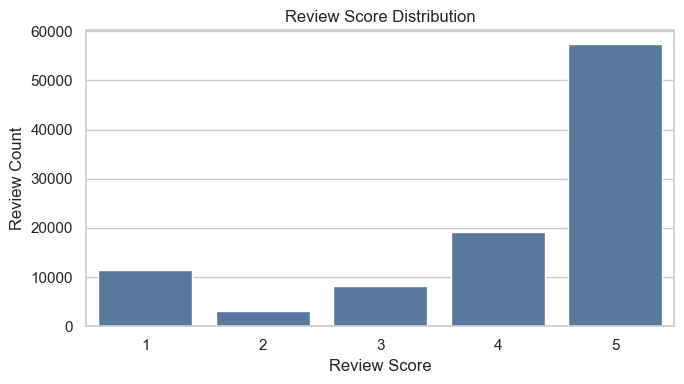

C:\Users\Farhan\AppData\Local\Temp\ipykernel_14064\1564055384.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=text_availability.index, y=text_availability.values, palette=['#59A14F', '#E15759'])


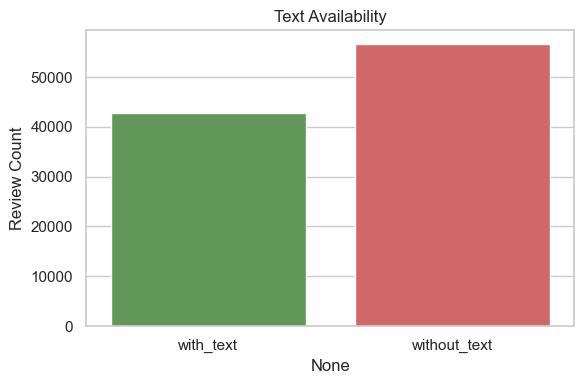

In [4]:
score_counts = reviews['review_score'].value_counts().sort_index()
plt.figure(figsize=(7, 4))
sns.barplot(x=score_counts.index, y=score_counts.values, color='#4C78A8')
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Review Count')
plt.tight_layout()
plt.savefig(ASSET_DIR / '01_review_score_distribution.png', dpi=150)
plt.show()

text_availability = pd.Series({'with_text': any_text.sum(), 'without_text': (~any_text).sum()})
plt.figure(figsize=(6, 4))
sns.barplot(x=text_availability.index, y=text_availability.values, palette=['#59A14F', '#E15759'])
plt.title('Text Availability')
plt.ylabel('Review Count')
plt.tight_layout()
plt.savefig(ASSET_DIR / '02_text_availability.png', dpi=150)
plt.show()

## 4. Combine Review Title and Message

In [5]:
df = reviews.copy()
df['review_text_raw'] = (
    df['review_comment_title'].fillna('').astype(str) + ' ' + df['review_comment_message'].fillna('').astype(str)
).str.replace(r'\s+', ' ', regex=True).str.strip()
df[['review_score', 'review_text_raw']].sample(8, random_state=42)

,review_score,review_text_raw
90252,5,
24436,5,Cumpriu o acordado!
11313,4,
75442,5,
7217,5,
72368,1,"Meu produto não foi entregue, sem me da nenhuma informação. Cancelaram meu pedido sem me informar de nada.Nao gostei"
63629,5,
71390,5,material excelente alticima qulidade otimo


## 5. Portuguese Text Cleaning

In [6]:
def normalize_accents(text):
    text = unicodedata.normalize('NFKD', str(text))
    return ''.join(char for char in text if not unicodedata.combining(char))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'[^a-záàâãéêíóôõúç0-9\s.,;:!?/-]', ' ', text)
    text = re.sub(r'([!?.,;:/-])\1+', r'\1', text)
    return re.sub(r'\s+', ' ', text).strip()

def normalize_text(text):
    text = normalize_accents(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['review_text_raw'].apply(clean_text)
df['normalized_text'] = df['clean_text'].apply(normalize_text)
df[['review_text_raw', 'clean_text', 'normalized_text']].head(10)

,review_text_raw,clean_text,normalized_text
0,,,
1,,,
2,,,
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado
4,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,parabéns lojas lannister adorei comprar pela internet seguro e prático parabéns a todos feliz páscoa,parabens lojas lannister adorei comprar pela internet seguro e pratico parabens a todos feliz pascoa
5,,,
6,,,
7,,,
8,,,
9,recomendo aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome...atualizar com a marca correta um...,recomendo aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome.atualizar com a marca correta uma ...,recomendo aparelho eficiente no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome atualizar com a marca correta uma v...


## 6. Phrase-Aware Preprocessing

In [7]:
PHRASE_REPLACEMENTS = [
    ('ainda nao recebi', 'nao_recebi'), ('nunca recebi', 'nao_recebi'), ('nao recebi', 'nao_recebi'),
    ('produto nao chegou', 'nao_chegou'), ('pedido nao chegou', 'nao_chegou'), ('nao chegou', 'nao_chegou'),
    ('nao foi entregue', 'nao_entregue'), ('nao entregue', 'nao_entregue'), ('consta entregue', 'consta_entregue'), ('marcado como entregue', 'marcado_entregue'),
    ('fora do prazo', 'fora_prazo'), ('dentro do prazo', 'dentro_prazo'), ('chegou antes', 'chegou_antes'), ('antes do prazo', 'antes_prazo'),
    ('produto errado', 'produto_errado'), ('veio errado', 'produto_errado'), ('veio outro', 'produto_errado'),
    ('produto diferente', 'produto_diferente'), ('veio diferente', 'produto_diferente'),
    ('veio faltando', 'produto_incompleto'), ('produto incompleto', 'produto_incompleto'), ('recebi somente', 'produto_incompleto'),
    ('tamanho errado', 'tamanho_errado'), ('cor errada', 'cor_errada'),
    ('produto quebrado', 'produto_quebrado'), ('produto danificado', 'produto_danificado'),
    ('pessima qualidade', 'qualidade_ruim'), ('qualidade ruim', 'qualidade_ruim'), ('baixa qualidade', 'baixa_qualidade'),
    ('nao funciona', 'nao_funciona'), ('nao funcionou', 'nao_funciona'), ('mal acabado', 'mal_acabado'),
    ('sem resposta', 'sem_resposta'), ('sem retorno', 'sem_resposta'), ('nao respondeu', 'sem_resposta'),
    ('pedi reembolso', 'pedi_reembolso'), ('pedi estorno', 'pedi_estorno'), ('dinheiro de volta', 'dinheiro_volta'), ('quero reembolso', 'quero_reembolso'),
    ('mal embalado', 'mal_embalado'), ('sem protecao', 'sem_protecao'), ('sem embalagem', 'sem_embalagem'),
]

def apply_phrases(text):
    phrase_text = f' {text} '
    for phrase, repl in PHRASE_REPLACEMENTS:
        phrase_text = phrase_text.replace(f' {phrase} ', f' {repl} ')
    return re.sub(r'\s+', ' ', phrase_text).strip()

def tokenize(text):
    return re.findall(NORMALIZED_TOKEN_PATTERN, str(text).lower())

df['phrase_text'] = df['normalized_text'].apply(apply_phrases)
df['token_count'] = df['clean_text'].apply(lambda x: len(re.findall(r'[a-záàâãéêíóôõúç]+', str(x).lower())))
df['has_text'] = df['token_count'] > 0
df['is_low_rating'] = df['review_score'] <= 2
df['is_high_rating'] = df['review_score'] >= 4
df[df['phrase_text'].str.contains('nao_recebi|nao_chegou|produto_errado|fora_prazo', regex=True, na=False)][['review_score', 'clean_text', 'phrase_text']].head(10)

,review_score,clean_text,phrase_text
19,1,não chegou meu produto péssimo,nao_chegou meu produto pessimo
32,1,"sempre compro pela internet e a entrega ocorre antes do prazo combinado, que acredito ser o prazo máximo. no stark o prazo máximo já se esgotou e ainda não ...",sempre compro pela internet e a entrega ocorre antes_prazo combinado que acredito ser o prazo maximo no stark o prazo maximo ja se esgotou e nao_recebi o pr...
68,1,"o produto não chegou no prazo estipulado e causou transtorno, pq programei a viagem de férias do meu filho, baseado no prazo. moro na bahia e ele em cuiabá ...",o nao_chegou no prazo estipulado e causou transtorno pq programei a viagem de ferias do meu filho baseado no prazo moro na bahia e ele em cuiaba sozinho ago...
104,3,não recebi o produto.,nao_recebi o produto
149,1,eu não recebi o produto e consta no sistema que eu recebi além de pagar caro do frete,eu nao_recebi o produto e consta no sistema que eu recebi alem de pagar caro do frete
169,1,fiz minha compra faz 30 dias e não recebi ainda meu produto. precisa melhorar nas entregas,fiz minha compra faz 30 dias e nao_recebi ainda meu produto precisa melhorar nas entregas
180,3,"comprei dois lustres pendentes, com a parceira targaryen e só me enviaram um lustre. abri reclamação, mas ainda não recebi resposta. aguardo solução por par...",comprei dois lustres pendentes com a parceira targaryen e so me enviaram um lustre abri reclamacao mas nao_recebi resposta aguardo solucao por parte de loja...
197,1,não recebi ainda aqui está descrevendo como entregue só que ate agora não recebi,nao_recebi ainda aqui esta descrevendo como entregue so que ate agora nao_recebi
241,1,o meu produto não chegou. segundo o rastreio está parado em ribeirão preto sp.,o meu nao_chegou segundo o rastreio esta parado em ribeirao preto sp
245,1,até agora não recebi o produto.,ate agora nao_recebi o produto


## 7. Library-Based Portuguese Stopwords + Custom Domain Rules

In [8]:
FALLBACK_STOPWORDS = {'a','ao','aos','as','com','como','da','das','de','do','dos','e','em','esta','este','eu','foi','foram','mais','mas','me','meu','minha','muito','na','nas','no','nos','o','os','ou','para','pela','pelo','por','que','se','seu','sua','tambem','tem','um','uma'}
NEGATIONS = {'nao', 'não', 'nunca', 'nem', 'sem'}
DOMAIN_STOPWORDS = {'lannister', 'stark', 'targaryen', 'baratheon'}
PROTECTED_PHRASES = {replacement for _, replacement in PHRASE_REPLACEMENTS}

try:
    from nltk.corpus import stopwords as nltk_stopwords
    library_stopwords = set(nltk_stopwords.words('portuguese'))
    stopword_source = 'NLTK Portuguese stopwords'
except Exception as exc:
    warnings.warn(f'NLTK stopwords unavailable, using fallback: {exc}')
    library_stopwords = set(FALLBACK_STOPWORDS)
    stopword_source = 'fallback Portuguese stopwords'

matching_stopwords = {normalize_text(w) for w in (library_stopwords | FALLBACK_STOPWORDS | DOMAIN_STOPWORDS)}
matching_stopwords -= {normalize_text(w) for w in NEGATIONS}
topic_stopwords = matching_stopwords | {'nao','produto','produtos','pedido','compra','comprei','recebi','veio','ainda','dia','dias','loja','entrega','entregue','chegou','comprado','comprar','agora','momento','apenas','somente','hoje','nada','quero','saber'}
topic_stopwords -= PROTECTED_PHRASES
stopword_source, len(matching_stopwords), len(topic_stopwords)

('NLTK Portuguese stopwords', 201, 226)

## 8. Preprocessing Sanity Check

In [9]:
df.loc[df['has_text'], ['review_score', 'review_text_raw', 'clean_text', 'normalized_text', 'phrase_text']].sample(10, random_state=11)

,review_score,review_text_raw,clean_text,normalized_text,phrase_text
80200,5,O produto foi entregue em 2 dias úteis.,o produto foi entregue em 2 dias úteis.,o produto foi entregue em 2 dias uteis,o produto foi entregue em 2 dias uteis
92132,5,Recomendo Ótima loja online,recomendo ótima loja online,recomendo otima loja online,recomendo otima loja online
54686,1,Não entregaram o produto certo e não querem entregar enquanto não devolvermos o errado Não irei devolver enquanto nao receber o certo,não entregaram o produto certo e não querem entregar enquanto não devolvermos o errado não irei devolver enquanto nao receber o certo,nao entregaram o produto certo e nao querem entregar enquanto nao devolvermos o errado nao irei devolver enquanto nao receber o certo,nao entregaram o produto certo e nao querem entregar enquanto nao devolvermos o errado nao irei devolver enquanto nao receber o certo
80406,4,Produto entregue dentro do prazo e a qualidade do produto parece muito boa!,produto entregue dentro do prazo e a qualidade do produto parece muito boa!,produto entregue dentro do prazo e a qualidade do produto parece muito boa,produto entregue dentro_prazo e a qualidade do produto parece muito boa
95578,5,"Gostei muito. O erro foi dos correios,que entregou o pacote no prédio em frente ao meu.Mas deu tudo certo.Muito obrigado.","gostei muito. o erro foi dos correios,que entregou o pacote no prédio em frente ao meu.mas deu tudo certo.muito obrigado.",gostei muito o erro foi dos correios que entregou o pacote no predio em frente ao meu mas deu tudo certo muito obrigado,gostei muito o erro foi dos correios que entregou o pacote no predio em frente ao meu mas deu tudo certo muito obrigado
31827,5,confiável,confiável,confiavel,confiavel
51650,5,Excelente É uma logística dinâmica que cumpre com suas responsabilidades,excelente é uma logística dinâmica que cumpre com suas responsabilidades,excelente e uma logistica dinamica que cumpre com suas responsabilidades,excelente e uma logistica dinamica que cumpre com suas responsabilidades
28251,1,Pela segunda vesz que eu compro um produto e voces não cumprem como esta no site.,pela segunda vesz que eu compro um produto e voces não cumprem como esta no site.,pela segunda vesz que eu compro um produto e voces nao cumprem como esta no site,pela segunda vesz que eu compro um produto e voces nao cumprem como esta no site
68387,1,a capa era de galaxy note 8 e veiod e galaxy s8 nao serve no celular,a capa era de galaxy note 8 e veiod e galaxy s8 nao serve no celular,a capa era de galaxy note 8 e veiod e galaxy s8 nao serve no celular,a capa era de galaxy note 8 e veiod e galaxy s8 nao serve no celular
24981,1,Falta confiabilidade Não confiavel,falta confiabilidade não confiavel,falta confiabilidade nao confiavel,falta confiabilidade nao confiavel


## 9. Negative vs Positive Review Analysis

In [10]:
low_text = df[df['is_low_rating'] & df['has_text']].copy()
high_text = df[df['is_high_rating'] & df['has_text']].copy()
print('Low-rating text reviews:', len(low_text))
print('High-rating text reviews:', len(high_text))
df.groupby('review_score')['token_count'].median().rename('median_token_count').to_frame()

Low-rating text reviews: 10978
High-rating text reviews: 27848


,median_token_count
review_score,
1,11.0
2,9.0
3,0.0
4,0.0
5,0.0


## 10. Word Frequency Low vs High

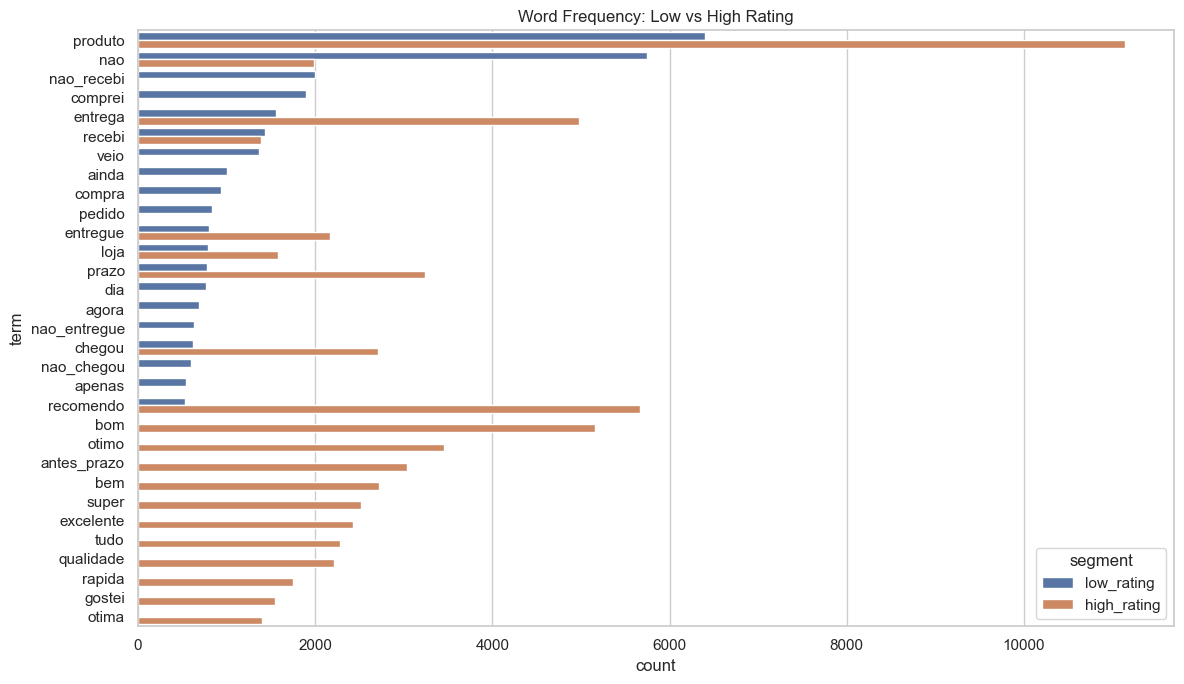

,term,count,segment
0,produto,6401,low_rating
1,nao,5749,low_rating
2,nao_recebi,1993,low_rating
3,comprei,1900,low_rating
4,entrega,1561,low_rating
5,recebi,1435,low_rating
6,veio,1367,low_rating
7,ainda,1001,low_rating
8,compra,933,low_rating
9,pedido,834,low_rating


In [11]:
def term_counter(texts, stopwords, ngram=1):
    counts = Counter()
    for text in texts:
        tokens = [t for t in tokenize(text) if t not in stopwords and len(t) > 1]
        if ngram == 1:
            counts.update(tokens)
        else:
            counts.update([' '.join(tokens[i:i+ngram]) for i in range(len(tokens)-ngram+1)])
    return counts

low_counts = term_counter(low_text['phrase_text'], matching_stopwords)
high_counts = term_counter(high_text['phrase_text'], matching_stopwords)
freq_df = pd.concat([
    pd.DataFrame(low_counts.most_common(20), columns=['term', 'count']).assign(segment='low_rating'),
    pd.DataFrame(high_counts.most_common(20), columns=['term', 'count']).assign(segment='high_rating'),
])

plt.figure(figsize=(12, 7))
sns.barplot(data=freq_df, x='count', y='term', hue='segment')
plt.title('Word Frequency: Low vs High Rating')
plt.tight_layout()
plt.savefig(ASSET_DIR / '03_word_frequency_low_vs_high.png', dpi=150)
plt.show()
freq_df.head(20)

## 11. TF-IDF Top Terms Low vs High

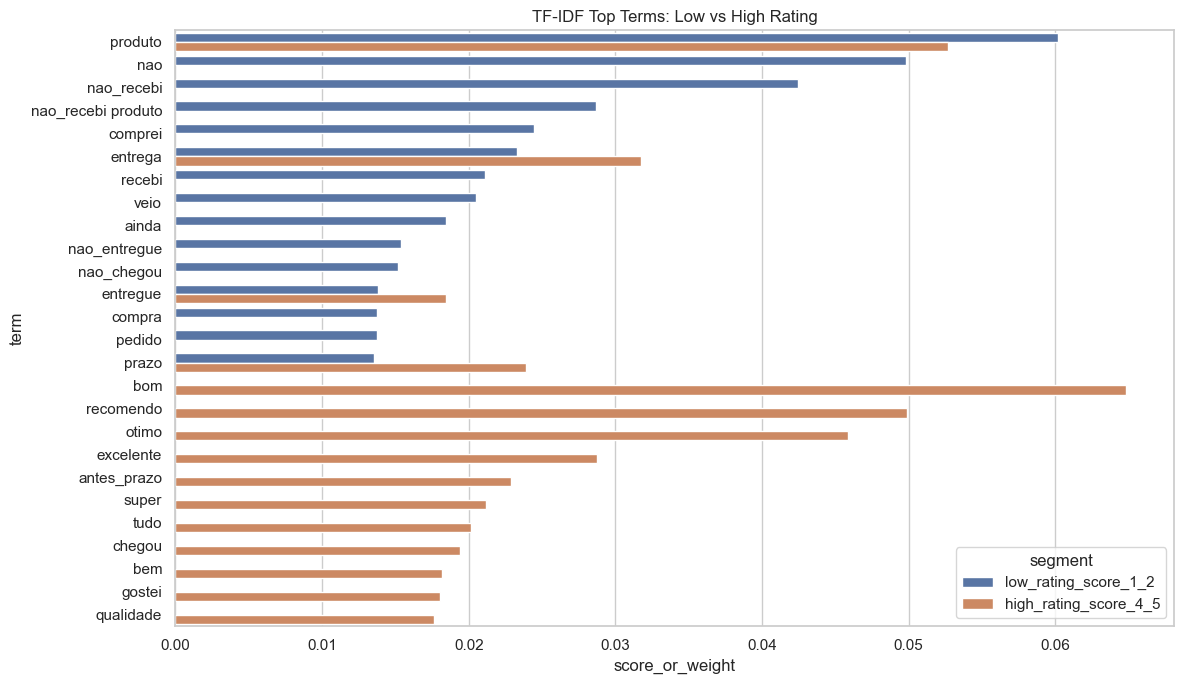

,segment,term,score_or_weight,raw_count
60,low_rating_score_1_2,produto,0.060200,6401
61,low_rating_score_1_2,nao,0.049822,5749
62,low_rating_score_1_2,nao_recebi,0.042451,1993
63,low_rating_score_1_2,nao_recebi produto,0.028689,1028
64,low_rating_score_1_2,comprei,0.024444,1900
65,low_rating_score_1_2,entrega,0.023269,1561
66,low_rating_score_1_2,recebi,0.021084,1435
67,low_rating_score_1_2,veio,0.020519,1367
68,low_rating_score_1_2,ainda,0.018428,1001
69,low_rating_score_1_2,nao_entregue,0.015350,628


In [12]:
def vectorizer_tokenizer(text):
    return tokenize(text)

def top_tfidf_terms(segment, texts, stopwords, top_n=30):
    vec = TfidfVectorizer(tokenizer=vectorizer_tokenizer, token_pattern=None, stop_words=sorted(stopwords), ngram_range=(1,2), min_df=5, max_df=0.8, max_features=3000)
    cnt = CountVectorizer(tokenizer=vectorizer_tokenizer, token_pattern=None, stop_words=sorted(stopwords), ngram_range=(1,2), min_df=5, max_df=0.8, max_features=3000)
    X = vec.fit_transform(texts)
    C = cnt.fit_transform(texts)
    terms = np.array(vec.get_feature_names_out())
    count_lookup = dict(zip(cnt.get_feature_names_out(), np.asarray(C.sum(axis=0)).ravel()))
    scores = np.asarray(X.mean(axis=0)).ravel()
    rows = []
    for idx in scores.argsort()[::-1][:top_n]:
        term = terms[idx]
        rows.append({'segment': segment, 'term': term, 'score_or_weight': round(float(scores[idx]), 6), 'raw_count': int(count_lookup.get(term, 0))})
    return rows

segments = {
    'review_score_1': df[(df['review_score'] == 1) & df['has_text']]['phrase_text'],
    'review_score_2': df[(df['review_score'] == 2) & df['has_text']]['phrase_text'],
    'low_rating_score_1_2': low_text['phrase_text'],
    'high_rating_score_4_5': high_text['phrase_text'],
    'all_text_reviews': df[df['has_text']]['phrase_text'],
}
top_terms = pd.DataFrame([row for seg, texts in segments.items() for row in top_tfidf_terms(seg, texts, matching_stopwords)])
plot_terms = top_terms[top_terms['segment'].isin(['low_rating_score_1_2', 'high_rating_score_4_5'])].groupby('segment').head(15)
plt.figure(figsize=(12, 7))
sns.barplot(data=plot_terms, x='score_or_weight', y='term', hue='segment')
plt.title('TF-IDF Top Terms: Low vs High Rating')
plt.tight_layout()
plt.savefig(ASSET_DIR / '04_tfidf_low_vs_high.png', dpi=150)
plt.show()
top_terms[top_terms['segment'].eq('low_rating_score_1_2')].head(20)

## 12. Mandatory Word Cloud Low vs High

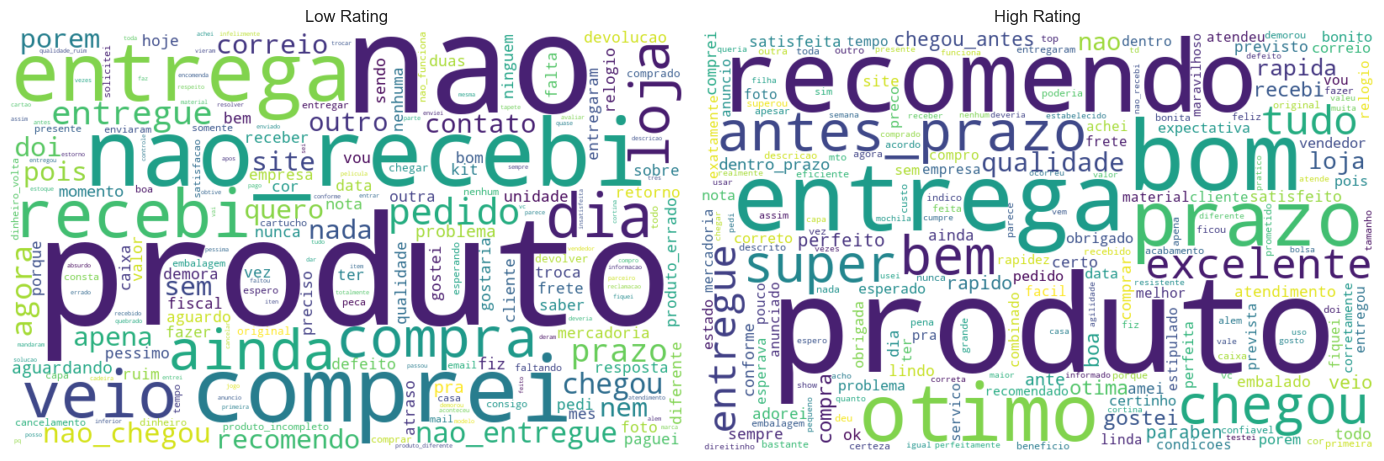

In [13]:
def make_wordcloud_text(texts, stopwords):
    tokens = []
    for text in texts:
        tokens.extend([t for t in tokenize(text) if t not in stopwords and len(t) > 1])
    return ' '.join(tokens)

low_wc_text = make_wordcloud_text(low_text['phrase_text'], matching_stopwords)
high_wc_text = make_wordcloud_text(high_text['phrase_text'], matching_stopwords)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, text, title in [(axes[0], low_wc_text, 'Low Rating'), (axes[1], high_wc_text, 'High Rating')]:
    wc = WordCloud(width=800, height=500, background_color='white', collocations=False, random_state=42).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig(ASSET_DIR / '05_wordcloud_low_vs_high.png', dpi=150)
plt.show()

## 13. Bigram Analysis Low vs High

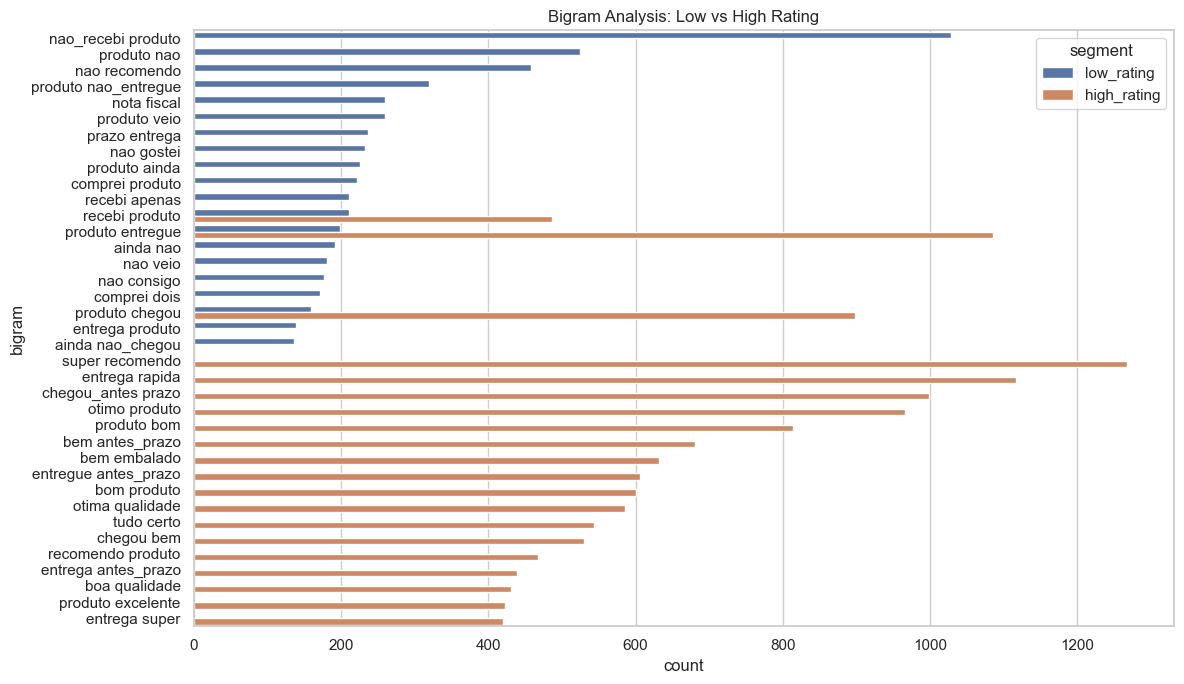

,bigram,count,segment
0,nao_recebi produto,1028,low_rating
1,produto nao,524,low_rating
2,nao recomendo,458,low_rating
3,produto nao_entregue,319,low_rating
4,nota fiscal,260,low_rating
5,produto veio,259,low_rating
6,prazo entrega,236,low_rating
7,nao gostei,232,low_rating
8,produto ainda,225,low_rating
9,comprei produto,221,low_rating


In [14]:
low_bigrams = pd.DataFrame(term_counter(low_text['phrase_text'], matching_stopwords, ngram=2).most_common(20), columns=['bigram', 'count']).assign(segment='low_rating')
high_bigrams = pd.DataFrame(term_counter(high_text['phrase_text'], matching_stopwords, ngram=2).most_common(20), columns=['bigram', 'count']).assign(segment='high_rating')
bigram_df = pd.concat([low_bigrams, high_bigrams])
plt.figure(figsize=(12, 7))
sns.barplot(data=bigram_df, x='count', y='bigram', hue='segment')
plt.title('Bigram Analysis: Low vs High Rating')
plt.tight_layout()
plt.savefig(ASSET_DIR / '06_bigram_low_vs_high.png', dpi=150)
plt.show()
bigram_df.head(20)

## 14. Rule-Based Multi-Label Theme Tagging

In [15]:
THEME_PATTERNS = {
    'theme_delivery_not_received': ['nao_recebi','nao_chegou','nao_entregue','aguardando','consta_entregue','marcado_entregue'],
    'theme_delivery_delay': ['atraso','atrasado','atrasada','atrasou','demora','demorou','fora_prazo','prazo','rastreio','transportadora','correios'],
    'theme_product_wrong_incomplete': ['produto_errado','produto_diferente','produto_incompleto','faltou','faltando','incompleto','diferente','tamanho_errado','cor_errada'],
    'theme_product_defect_quality': ['defeito','defeituoso','defeituosa','quebrado','quebrada','quebrados','danificado','danificada','danificados','qualidade_ruim','baixa_qualidade','pessimo','ruim','nao_funciona','mal_acabado'],
    'theme_seller_service_refund': ['reembolso','estorno','devolucao','pedi_reembolso','pedi_estorno','dinheiro_volta','quero_reembolso','atendimento','sem_resposta','contato','vendedor','reclamei','troca'],
    'theme_positive_recommendation': ['recomendo','gostei','otimo','excelente','perfeito','chegou_antes','dentro_prazo','antes_prazo','satisfeito','satisfeita'],
    'theme_packaging_issue': ['embalagem','caixa','pacote','aberto','rasgado','amassado','mal_embalado','sem_protecao','sem_embalagem'],
}
THEME_LABELS = {
    'theme_delivery_not_received': 'Delivery - Not Received', 'theme_delivery_delay': 'Delivery - Delay',
    'theme_product_wrong_incomplete': 'Product - Wrong/Incomplete', 'theme_product_defect_quality': 'Product - Defect/Quality',
    'theme_seller_service_refund': 'Seller/Service/Refund', 'theme_positive_recommendation': 'Positive Recommendation',
    'theme_packaging_issue': 'Packaging Issue', 'theme_other': 'Other Complaint'
}

def has_positive_signal(text, pattern):
    if pattern in {'recomendo','gostei','otimo','excelente','perfeito','satisfeito','satisfeita'}:
        return bool(re.search(rf'(?<!nao )(?<!nunca )(?<!nem )(?<!sem ){pattern}', text))
    return pattern in text

theme_tags = df[['review_id', 'order_id', 'review_score', 'phrase_text']].copy()
for theme, patterns in THEME_PATTERNS.items():
    if theme == 'theme_positive_recommendation':
        theme_tags[theme] = theme_tags['phrase_text'].apply(lambda text: any(has_positive_signal(text, p) for p in patterns))
    else:
        theme_tags[theme] = theme_tags['phrase_text'].apply(lambda text: any(p in text for p in patterns))
theme_cols = list(THEME_PATTERNS.keys())
theme_tags['theme_count'] = theme_tags[theme_cols].sum(axis=1).astype(int)
theme_tags['theme_other'] = theme_tags['theme_count'].eq(0)
theme_tags['theme_count'] = theme_tags[theme_cols + ['theme_other']].sum(axis=1).astype(int)
theme_tags = theme_tags[['review_id','order_id','review_score', *theme_cols, 'theme_other','theme_count']]
theme_tags.head()

,review_id,order_id,review_score,theme_delivery_not_received,theme_delivery_delay,theme_product_wrong_incomplete,theme_product_defect_quality,theme_seller_service_refund,theme_positive_recommendation,theme_packaging_issue,theme_other,theme_count
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,False,False,False,False,False,False,False,True,1
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,False,False,False,False,False,False,False,True,1
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,False,False,False,False,False,False,False,True,1
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,False,True,False,False,False,True,False,False,2
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,False,False,False,False,False,False,False,True,1


## 15. Theme Summary for Low-Rating Reviews

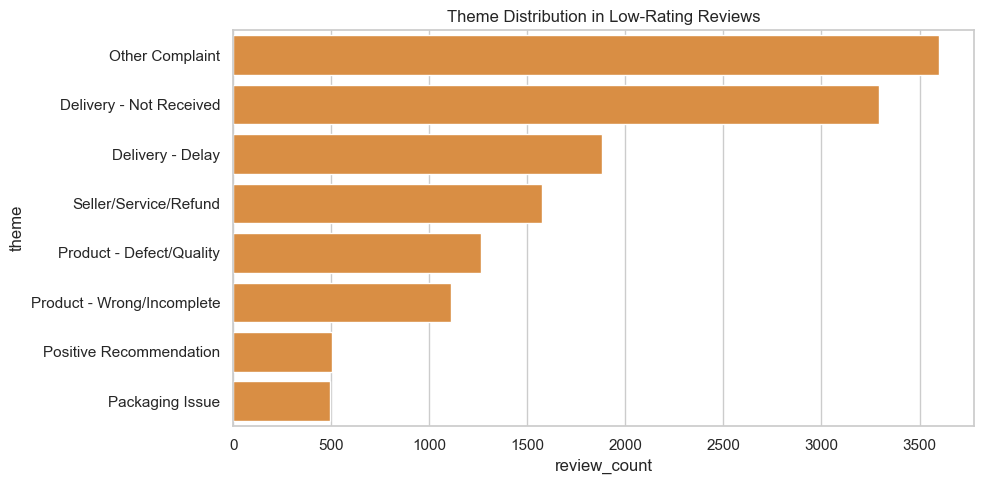

,theme,review_count,percentage_of_low_rating_reviews,avg_review_score,sample_keywords
7,Other Complaint,3598,33.18,1.23,no matched theme
0,Delivery - Not Received,3293,30.36,1.12,"nao_recebi, nao_chegou, nao_entregue, aguardando, consta_entregue, marcado_entregue"
1,Delivery - Delay,1879,17.33,1.23,"atraso, atrasado, atrasada, atrasou, demora, demorou, fora_prazo, prazo"
4,Seller/Service/Refund,1572,14.50,1.13,"reembolso, estorno, devolucao, pedi_reembolso, pedi_estorno, dinheiro_volta, quero_reembolso, atendimento"
3,Product - Defect/Quality,1264,11.66,1.19,"defeito, defeituoso, defeituosa, quebrado, quebrada, quebrados, danificado, danificada"
2,Product - Wrong/Incomplete,1109,10.23,1.20,"produto_errado, produto_diferente, produto_incompleto, faltou, faltando, incompleto, diferente, tamanho_errado"
5,Positive Recommendation,504,4.65,1.34,"recomendo, gostei, otimo, excelente, perfeito, chegou_antes, dentro_prazo, antes_prazo"
6,Packaging Issue,491,4.53,1.25,"embalagem, caixa, pacote, aberto, rasgado, amassado, mal_embalado, sem_protecao"


In [16]:
low_ids_with_text = set(low_text['review_id'])
summary_rows = []
denominator = max(len(low_ids_with_text), 1)
for col in theme_cols + ['theme_other']:
    matched = theme_tags[theme_tags['review_id'].isin(low_ids_with_text) & theme_tags[col]]
    summary_rows.append({
        'theme': THEME_LABELS[col],
        'review_count': int(len(matched)),
        'percentage_of_low_rating_reviews': round(len(matched) * 100 / denominator, 2),
        'avg_review_score': round(float(matched['review_score'].mean()), 2) if len(matched) else None,
        'sample_keywords': ', '.join(THEME_PATTERNS.get(col, ['no matched theme'])[:8])
    })
theme_summary = pd.DataFrame(summary_rows).sort_values('review_count', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=theme_summary, x='review_count', y='theme', color='#F28E2B')
plt.title('Theme Distribution in Low-Rating Reviews')
plt.tight_layout()
plt.savefig(ASSET_DIR / '07_theme_distribution_low_rating.png', dpi=150)
plt.show()
theme_summary

## 16. Theme Heatmap by Review Score

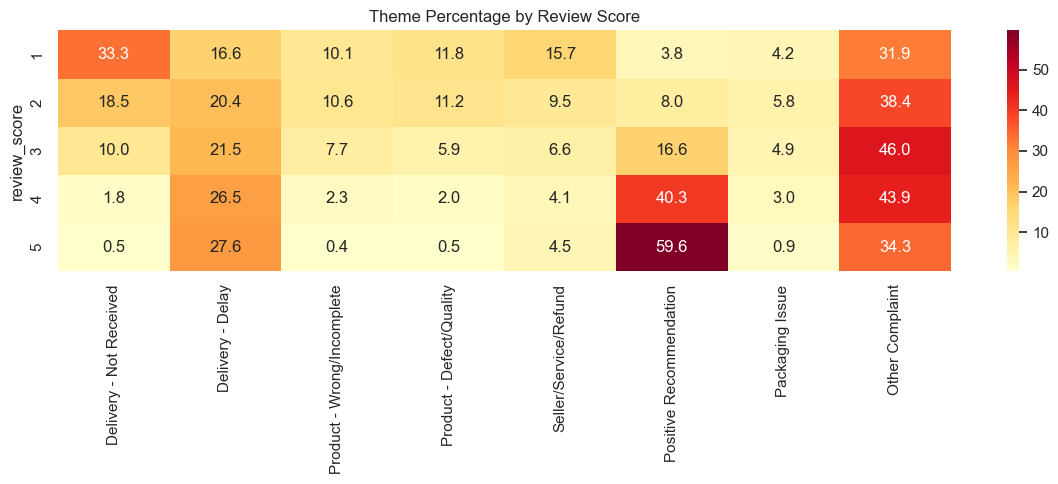

,Delivery - Not Received,Delivery - Delay,Product - Wrong/Incomplete,Product - Defect/Quality,Seller/Service/Refund,Positive Recommendation,Packaging Issue,Other Complaint
review_score,,,,,,,,
1,33.279761,16.565262,10.136609,11.755252,15.715762,3.834233,4.224544,31.902193
2,18.462980,20.431115,10.590440,11.246485,9.512652,7.966261,5.763824,38.378632
3,10.000000,21.527778,7.666667,5.888889,6.611111,16.555556,4.916667,45.972222
4,1.827001,26.515764,2.344382,1.972514,4.106710,40.339531,2.958771,43.912692
5,0.534685,27.622280,0.446346,0.516087,4.505300,59.624326,0.934536,34.331412


In [17]:
heatmap_rows = []
for score in sorted(df['review_score'].dropna().unique()):
    score_ids = set(df[(df['review_score'] == score) & df['has_text']]['review_id'])
    denom = max(len(score_ids), 1)
    row = {'review_score': score}
    for col in theme_cols + ['theme_other']:
        row[THEME_LABELS[col]] = theme_tags[theme_tags['review_id'].isin(score_ids) & theme_tags[col]].shape[0] * 100 / denom
    heatmap_rows.append(row)
theme_heatmap = pd.DataFrame(heatmap_rows).set_index('review_score')
plt.figure(figsize=(12, 5))
sns.heatmap(theme_heatmap, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Theme Percentage by Review Score')
plt.tight_layout()
plt.savefig(ASSET_DIR / '08_theme_heatmap_by_score.png', dpi=150)
plt.show()
theme_heatmap

## 17. Sample Reviews per Major Theme

In [18]:
sample_rows = []
for col in theme_cols:
    ids = theme_tags[theme_tags[col] & theme_tags['review_score'].le(2)]['review_id'].head(3)
    sample = df[df['review_id'].isin(ids)][['review_id','review_score','clean_text']].copy()
    sample.insert(0, 'theme', THEME_LABELS[col])
    sample_rows.append(sample)
theme_samples = pd.concat(sample_rows, ignore_index=True)
theme_samples

,theme,review_id,review_score,clean_text
0,Delivery - Not Received,373cbeecea8286a2b66c97b1b157ec46,1,não chegou meu produto péssimo
1,Delivery - Not Received,58044bca115705a48fe0e00a21390c54,1,"sempre compro pela internet e a entrega ocorre antes do prazo combinado, que acredito ser o prazo máximo. no stark o prazo máximo já se esgotou e ainda não ..."
2,Delivery - Not Received,6d06808638ec0701bccd70bc8d462c28,1,"o produto não chegou no prazo estipulado e causou transtorno, pq programei a viagem de férias do meu filho, baseado no prazo. moro na bahia e ele em cuiabá ..."
3,Delivery - Delay,58044bca115705a48fe0e00a21390c54,1,"sempre compro pela internet e a entrega ocorre antes do prazo combinado, que acredito ser o prazo máximo. no stark o prazo máximo já se esgotou e ainda não ..."
4,Delivery - Delay,6d06808638ec0701bccd70bc8d462c28,1,"o produto não chegou no prazo estipulado e causou transtorno, pq programei a viagem de férias do meu filho, baseado no prazo. moro na bahia e ele em cuiabá ..."
5,Delivery - Delay,5c37d7ba6ef2f031c34bb4fda3454018,2,demorou de mais pra entrega
6,Product - Wrong/Incomplete,e233e51d11511bf30e568c76360ace52,1,recebi somente 1 controle midea split estilo. faltou controle remoto para ar condicionado consul
7,Product - Wrong/Incomplete,c40a6b6e0181e5ec0d12cbc2e12c49d3,1,falta de produto e quebra faltou 1 produto e os que recebi 1 veio quebrado
8,Product - Wrong/Incomplete,3ff8285931cc9b54c9ad22ba78957f63,1,comprei dois produtos e recebi somente um. mandei dois emails para a loja e não tive nenhum retorno. estou insatisfeita.
9,Product - Defect/Quality,373cbeecea8286a2b66c97b1b157ec46,1,não chegou meu produto péssimo


## 18. NMF Topic Modeling Baseline

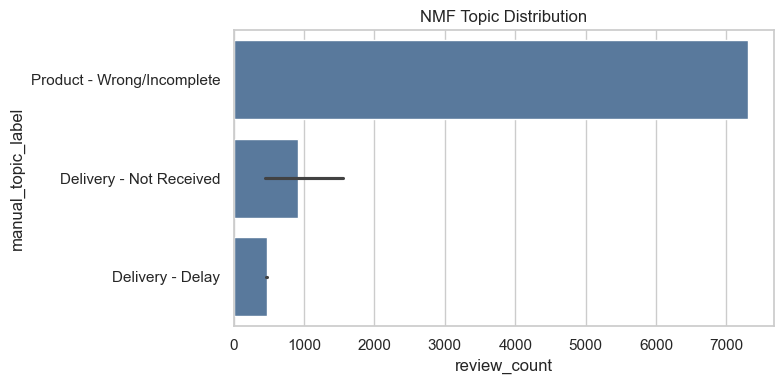

,topic_id,top_terms,manual_topic_label,review_count
3,3,"dois, recomendo, nota, defeito, outro, produto_errado, site, sem, fiscal, nem, nota fiscal, pois",Product - Wrong/Incomplete,7310
0,0,"nao_recebi, nao_recebi nao_recebi, nao_recebi mercadoria, avaliar, nao_recebi nem, mercadoria, posso, pois nao_recebi, nem, data, prazo nao_recebi, nenhuma",Delivery - Not Received,1556
4,4,"prazo, passou, passou prazo, prazo nao_recebi, nao_recebi prazo, longo, nao_entregue prazo, nao_chegou prazo, atraso, assim, prazo longo, chegar",Delivery - Not Received,732
1,1,"nao_entregue, nao_entregue nao_entregue, nao_entregue prazo, presente, data, mes, demora, mercadoria nao_entregue, previsao, pago, mercadoria, nao_entregue ...",Delivery - Delay,479
2,2,"nao_chegou, mercadoria, nao_chegou prazo, esperando, mes, data, faz, correios, prazo nao_chegou, previsao, consta, residencia",Delivery - Delay,462
5,5,"aguardando, retorno, aguardando retorno, nao_recebi aguardando, aguardando resposta, resposta, chegar, contato, aguardando contato, solucao, envio, aguardan...",Delivery - Not Received,439


In [19]:
def label_topic(top_terms):
    joined = ' '.join(top_terms)
    scores = {theme: sum(1 for p in patterns if p in joined) for theme, patterns in THEME_PATTERNS.items()}
    best, score = max(scores.items(), key=lambda item: item[1])
    return THEME_LABELS[best] if score > 0 else 'Other Complaint'

def topic_rows(model, vectorizer, doc_topic_matrix):
    terms = np.array(vectorizer.get_feature_names_out())
    dominant = doc_topic_matrix.argmax(axis=1)
    counts = Counter(dominant)
    rows = []
    for topic_id, weights in enumerate(model.components_):
        top = terms[weights.argsort()[::-1][:12]].tolist()
        rows.append({'topic_id': int(topic_id), 'top_terms': ', '.join(top), 'manual_topic_label': label_topic(top), 'review_count': int(counts.get(topic_id, 0))})
    return pd.DataFrame(rows).sort_values('review_count', ascending=False)

nmf_vectorizer = TfidfVectorizer(tokenizer=vectorizer_tokenizer, token_pattern=None, stop_words=sorted(topic_stopwords), ngram_range=(1,2), min_df=10, max_df=0.6, max_features=2500)
X_nmf = nmf_vectorizer.fit_transform(low_text['phrase_text'])
nmf_model = NMF(n_components=6, random_state=42, init='nndsvda', max_iter=500)
W_nmf = nmf_model.fit_transform(X_nmf)
nmf_topics = topic_rows(nmf_model, nmf_vectorizer, W_nmf)
plt.figure(figsize=(8, 4))
sns.barplot(data=nmf_topics, x='review_count', y='manual_topic_label', color='#4E79A7')
plt.title('NMF Topic Distribution')
plt.tight_layout()
plt.savefig(ASSET_DIR / '09_nmf_topic_distribution.png', dpi=150)
plt.show()
nmf_topics

## 19. LDA Topic Modeling Exploratory

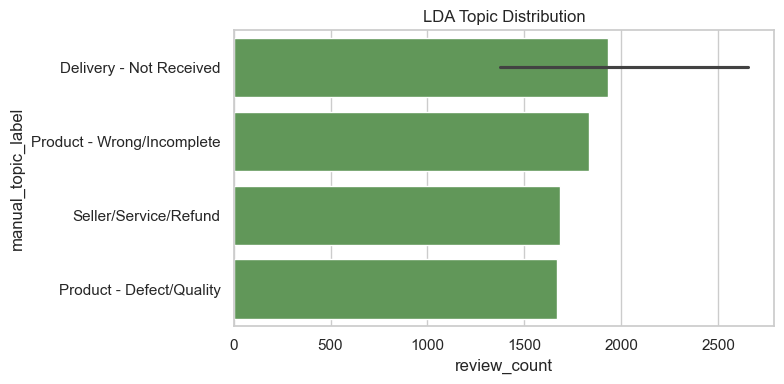

,topic_id,top_terms,manual_topic_label,review_count
3,3,"nao_recebi, nao_chegou, prazo, correios, mercadoria, nem, contato, retorno, problema, nao_entregue, aguardo, paguei",Delivery - Not Received,2656
4,4,"dois, nota, duas, fiscal, nota fiscal, valor, unidades, pedi, produto_incompleto, paguei, faltando, entregaram",Product - Wrong/Incomplete,1833
2,2,"nao_entregue, prazo, recomendo, falta, mes, vez, nunca, cliente, ruim, sem, bom, compro",Delivery - Not Received,1758
5,5,"defeito, troca, produto_errado, devolucao, aguardando, solicitei, caixa, outro, porem, contato, nao_funciona, pois",Seller/Service/Refund,1685
0,0,"gostei, cor, foto, bem, diferente, qualidade, original, relogio, qualidade_ruim, site, anuncio, achei",Product - Defect/Quality,1671
1,1,"demora, nenhuma, ter, nao_recebi, pessimo, pra, estoque, nem, avaliar, posso, n, resposta",Delivery - Not Received,1375


In [20]:
lda_vectorizer = CountVectorizer(tokenizer=vectorizer_tokenizer, token_pattern=None, stop_words=sorted(topic_stopwords), ngram_range=(1,2), min_df=10, max_df=0.6, max_features=2500)
X_lda = lda_vectorizer.fit_transform(low_text['phrase_text'])
lda_model = LatentDirichletAllocation(n_components=6, random_state=42, learning_method='batch', max_iter=30)
W_lda = lda_model.fit_transform(X_lda)
lda_topics = topic_rows(lda_model, lda_vectorizer, W_lda)
plt.figure(figsize=(8, 4))
sns.barplot(data=lda_topics, x='review_count', y='manual_topic_label', color='#59A14F')
plt.title('LDA Topic Distribution')
plt.tight_layout()
plt.savefig(ASSET_DIR / '10_lda_topic_distribution.png', dpi=150)
plt.show()
lda_topics

## 20. BERTopic Semantic Topic Modeling

In [21]:
bertopic_topics = pd.DataFrame(columns=['topic_id', 'topic_name', 'representative_terms', 'review_count', 'sample_reviews', 'mapped_business_label'])
bertopic_status = 'not_run'
try:
    from bertopic import BERTopic
    bertopic_sample = low_text.sample(min(8000, len(low_text)), random_state=42).copy()
    topic_model = BERTopic(embedding_model='paraphrase-multilingual-MiniLM-L12-v2', language='multilingual', calculate_probabilities=False, verbose=True, min_topic_size=50)
    topics, _ = topic_model.fit_transform(bertopic_sample['clean_text'].tolist())
    bertopic_sample['topic_id'] = topics
    info = topic_model.get_topic_info()
    rows = []
    for _, row in info.iterrows():
        tid = int(row['Topic'])
        if tid == -1:
            continue
        terms = [term for term, _ in topic_model.get_topic(tid)[:12]]
        topic_reviews = bertopic_sample[bertopic_sample['topic_id'].eq(tid)]['clean_text'].head(3).tolist()
        rows.append({'topic_id': tid, 'topic_name': row.get('Name', f'Topic {tid}'), 'representative_terms': ', '.join(terms), 'review_count': int(row['Count']), 'sample_reviews': ' || '.join(topic_reviews), 'mapped_business_label': label_topic(terms)})
    bertopic_topics = pd.DataFrame(rows).sort_values('review_count', ascending=False)
    if len(bertopic_topics):
        plt.figure(figsize=(8, 4))
        sns.barplot(data=bertopic_topics.head(10), x='review_count', y='mapped_business_label', color='#B07AA1')
        plt.title('BERTopic Topic Distribution')
        plt.tight_layout()
        plt.savefig(ASSET_DIR / '11_bertopic_topic_distribution.png', dpi=150)
        plt.show()
    bertopic_status = 'success'
except Exception as exc:
    bertopic_status = f'skipped_or_failed: {exc}'
    print('BERTopic skipped/failed:', exc)

bertopic_status, bertopic_topics.head(10)

c:\Users\Farhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Farhan\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance(

BERTopic skipped/failed: name 'nn' is not defined


("skipped_or_failed: name 'nn' is not defined",
 Empty DataFrame
 Columns: [topic_id, topic_name, representative_terms, review_count, sample_reviews, mapped_business_label]
 Index: [])

## 21. Compare Rule-Based Themes, NMF, LDA, and BERTopic

In [22]:
method_comparison = pd.DataFrame([
    {'method': 'Rule-based theme tagging', 'interpretability': 'High', 'semantic_capability': 'Low-Medium', 'runtime_dependency': 'Low', 'dashboard_usefulness': 'High', 'note': 'Main business output'},
    {'method': 'TF-IDF / NMF', 'interpretability': 'Medium-High', 'semantic_capability': 'Medium', 'runtime_dependency': 'Low', 'dashboard_usefulness': 'Medium-High', 'note': 'Preferred lightweight topic model'},
    {'method': 'LDA', 'interpretability': 'Medium', 'semantic_capability': 'Low-Medium', 'runtime_dependency': 'Low', 'dashboard_usefulness': 'Exploratory', 'note': 'Can be noisy for short reviews'},
    {'method': 'BERTopic', 'interpretability': 'Variable', 'semantic_capability': 'High', 'runtime_dependency': 'High', 'dashboard_usefulness': 'Exploratory/Advanced', 'note': bertopic_status},
])
method_comparison

,method,interpretability,semantic_capability,runtime_dependency,dashboard_usefulness,note
0,Rule-based theme tagging,High,Low-Medium,Low,High,Main business output
1,TF-IDF / NMF,Medium-High,Medium,Low,Medium-High,Preferred lightweight topic model
2,LDA,Medium,Low-Medium,Low,Exploratory,Can be noisy for short reviews
3,BERTopic,Variable,High,High,Exploratory/Advanced,skipped_or_failed: name 'nn' is not defined


## 22. Save CSV/JSON/PNG Outputs

In [23]:
cleaned_cols = ['review_id','order_id','review_score','review_text_raw','clean_text','normalized_text','phrase_text','token_count','has_text','is_low_rating','is_high_rating']
df[cleaned_cols].to_csv(OUT_DIR / 'review_text_cleaned_v2.csv', index=False)
theme_tags.to_csv(OUT_DIR / 'review_theme_tags_v2.csv', index=False)
theme_summary.to_csv(OUT_DIR / 'review_theme_summary_v2.csv', index=False)
top_terms.to_csv(OUT_DIR / 'review_top_terms_by_score_v2.csv', index=False)
nmf_topics.to_csv(OUT_DIR / 'review_topics_nmf_v2.csv', index=False)
lda_topics.to_csv(OUT_DIR / 'review_topics_lda_v2.csv', index=False)
if len(bertopic_topics):
    bertopic_topics.to_csv(OUT_DIR / 'review_topics_bertopic_v2.csv', index=False)

audit = dict(audit_base)
audit['median_token_count_all_text'] = float(df.loc[df['has_text'], 'token_count'].median())
audit['median_token_count_low_rating_text'] = float(df.loc[df['is_low_rating'] & df['has_text'], 'token_count'].median())
audit['bertopic_status'] = bertopic_status
(OUT_DIR / 'review_nlp_audit_v2.json').write_text(json.dumps(audit, indent=2), encoding='utf-8')
audit

{'total_reviews': 99224,
 'reviews_with_any_text': 42687,
 'low_rating_reviews': 14575,
 'low_rating_reviews_with_text': 10994,
 'percentage_reviews_with_text': 43.02,
 'percentage_low_rating_with_text': 75.43,
 'median_token_count_all_text': 9.0,
 'median_token_count_low_rating_text': 16.0,
 'bertopic_status': "skipped_or_failed: name 'nn' is not defined"}

## 23. Final Insight Summary and Limitations

- Low-rating reviews with text are relatively rich for root-cause analysis compared with all reviews.
- Low-rating text is dominated by delivery not received, delay, service/refund, and product quality signals.
- High-rating text tends to emphasize positive terms such as recommendation and satisfaction.
- Rule-based theme tagging is the main dashboard/business output because it is auditable.
- NMF is the preferred lightweight topic model; LDA remains exploratory.
- BERTopic is attempted as semantic topic modeling, but may be dependency-heavy or unavailable.
- Word cloud is useful for presentation, but not statistical proof.
- This NLP analysis is descriptive and not causal proof, and review text must not be used as ML prediction input.